# Set up of packages install

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 44.5 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
checkpoint_dir = "/content/drive/MyDrive/qLora_pt"

Mounted at /content/drive


Using device: cuda


# Part 1: Load/Analyze Data

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

databricks-dolly-15k.jsonl:   0%|          | 0.00/13.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/15011 [00:00<?, ? examples/s]

In [ ]:
print(ds)

DatasetDict({
    train: Dataset({
        features: ['instruction', 'context', 'response', 'category'],
        num_rows: 15011
    })
})


In [ ]:
len(ds)

1

In [ ]:
# category check
train = ds['train']
print(train)
print(train['category'])
# I don't know why, but the catergories they showed is different

Dataset({
    features: ['instruction', 'context', 'response', 'category'],
    num_rows: 15011
})
Column(['closed_qa', 'classification', 'open_qa', 'open_qa', 'closed_qa'])


In [ ]:
# category ratio
category_dict = {}
for row in train:
    category = row['category']
    if category in category_dict:
        category_dict[category] += 1
    else:
        category_dict[category] = 1

In [ ]:
print(category_dict)

{'closed_qa': 1773, 'classification': 2136, 'open_qa': 3742, 'information_extraction': 1506, 'brainstorming': 1766, 'general_qa': 2191, 'summarization': 1188, 'creative_writing': 709}


##What is your dataset? Please describe your dataset and where you got it

Databricks-Dolly-15k is an open-source instruction-following dataset consisting of 15,011 records created by thousands of Databricks employees. The dataset covers several task categories inspired by the InstructGPT paper, including brainstorming, classification, closed-question answering, generation, information extraction, open-question answering, and summarization. Each record contains three text fields: instruction, context, and response.
In this project, I used the dataset to fine-tune an LLM for instruction-following tasks. I split the full dataset into training, validation, and test sets using an 8:1:1 ratio. For each example, the instruction and optional context were combined to form the input prompt, while the response was used as the target output. During preprocessing, these fields were formatted into a structured prompt so that the model could learn to generate an appropriate response conditioned on the given instruction and context.
Because the model is a causal language model, the input and target were concatenated into a single sequence during training. However, the loss was computed only on the response tokens, while the instruction and context tokens were masked out. This setup allows the model to use the instruction and context as guidance while learning to produce the correct response. The training set was used to update model parameters, the validation set was used to monitor performance and tune training settings, and the test set was reserved for final evaluation of how well the fine-tuned model generalizes to unseen examples.

In [ ]:
# Data preprocessing
class DollyDataset(Dataset):
    def __init__(self, dataset, tokenizer, max_length):
        self.dataset = dataset
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        ex = self.dataset[idx]
        instruction = ex["instruction"].strip()
        context = ex.get("context", "").strip()
        response = ex["response"].strip()

        if context:
            prompt = (
                f"### Instruction:\n{instruction}\n\n"
                f"### Context:\n{context}\n\n"
                f"### Response:\n"
            )
        else:
            prompt = f"### Instruction:\n{instruction}\n\n### Response:\n"

        full_text = prompt + response

        full_enc = self.tokenizer(
            full_text,
            truncation=True,
            max_length=self.max_length,
            padding="max_length",
            return_tensors="pt",
        )
        prompt_enc = self.tokenizer(
            prompt,
            truncation=True,
            max_length=self.max_length,
            padding="max_length",
            return_tensors="pt",
        )
        # make it vector
        input_ids = full_enc["input_ids"].squeeze(0)
        attention_mask = full_enc["attention_mask"].squeeze(0)

        # labels for causal LM (autoregressive)
        labels = input_ids.clone()
        prompt_len = int(prompt_enc["attention_mask"].sum())
        # assign -100 for parts except for response tokens so that loss will be calculated just by response tokens
        labels[:prompt_len] = -100
        labels[attention_mask == 0] = -100

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels,
        }

# Part 2. Literature review

I picked the method of fine tuning as my research focus rather than model itself. I have seen trend of optimizing training process or model memory, and I think this assignment is good chance to catch up those techniques in llm field. I chose LoRA(Low Rank Adaption) https://arxiv.org/abs/2106.09685 and QLoRA(quantization LoRA) https://arxiv.org/pdf/2305.14314.
These are methods of fine-tuning. First of all, llm has two steps of main lerning process. Pretraining, which we learn in the class. The LLM trained on big texts data, and it will learn general language ability. The next step is fine tuning. This is basically for improving model ability in a specific way based on dataset. The process of fine-tuning is pretty similar to pretraining. Give them a input, and compare the generated outputs with labels, and do backprop to oprimize model weights. However, as model gets larger, changing original model weights takes huge memory and time. For example, the size of GPT 3 is 175B. If you do full fine-tuning, then you need to access 175B params all for back propagation, which is time-consuming.
The technique to avoid this is LoRA. LoRA is basically adding "adapter layer" to as new updated parameters as matrix multiplication AB, and updating AB parameters instead of updating W. Suppose update on the original weights is ΔW. Then we can describe new weights as W + ΔW. Updated weights will be W + AB, where A and B have much lower dimensions than W. Suppose W is d⋅k matrix, where d is dimension of input vector. Then with rank r, A is d⋅r matrix, and B is r⋅k matrix, so AB will be d⋅k matrix. This works only when ΔW is low rank r matrix, and columns of ΔW can be described by linear combinations of r columns. This is found in 2021 by Microsoft. They got inspiration from Li et al. https://arxiv.org/pdf/1804.08838 and Aghajanyan et al. https://arxiv.org/abs/2012.13255 which show that the learned over-parametrized models reside on a low intrinsic dimension, and hypothesized that change in weights updates during model adaptation also has low intrinsic dimension.
During forward propagation,for input X, output y = WX + ABX, and in backprop, only updates AB. Assuming you picked rank r, then for each layer the number of updated parameters will be d⋅r + r⋅k = r(d+k). On the other hand, in full fine-tuning, the number of updated parametes will be d⋅k per layer. Assume, d = 10000, and k = 2000 because it is LLM. r is often picked 32 or 16. Then d⋅k = 20000000, and r(d+k) = 32⋅12000=384000. Ratio of accessed weights between LoRA and full fine-tuning is 0.0192 per layer. This is amazing optimization in time, and allow us to fine tune huge model with single GPU.
The second method is QLoRA. The architecture is same as LoRA, but it will use quantization technique to store model parameters, which achieves smaller model in memory. This is found in 2023 by strudents from University of Washinton. Usually weights are stored in floating points 32 bits with 1 bit for sign, 8bits for exponent, and 23bits for Mantissa (precision). However, Google brain found brain floating 16 bits (bf16bits), which has 1 sign bit, 8 exponent bits, and 7 Mantissa bits https://arxiv.org/pdf/1905.12322. Exponents part has same bits as floating 32 bits, so it has identical range as 32 bits, but lose precision bits. Neural networks are far more sensitive to the size of the exponent than that of the mantissa because of overflows or underflows. To ensure identical behavior for underflows, overflows, and NaNs, bfloat16 has the same exponent size as FP32. This is often used for computation in NNs to save memory in half. QLoRA applies this in computation, but they stored original model weights in NormalFloat 4 bits(NF4) by quantization, and dequantize to bf16bits when it's computed. NF4 is information theoretically optimal 4 bit datatype. This will save a lot of memory from 32 to 4 bits maintaining precision. This technique allows us to train model in even single GPU.
Basically forward pass will be YBF16 = XBF16⋅Dequant(cFP32, WNF4) +XBF16⋅
ABF16⋅ BBF16.
I will implement this using package from huggingface BitsAndBytes to set store bits as NF4 and computation bits as bfloat16.

# Part 3. Implement Models (LoRA layer)

**LoRA from Scratch**
my code based on https://apxml.com/courses/lora-peft-efficient-llm-training/chapter-2-lora-in-depth/implementing-lora-layers

https://lightning.ai/lightning-ai/templates/code-lora-from-scratch?section=featured

I refered those above, and modified the part that matches for my implementation

In [ ]:
class LayerWithLoRA(nn.Module):
    """
    represents updated layer with LoRA layer attached to a given base layer
    """
    def __init__(self, base_layer, rank, alpha):
        super().__init__()
        self.base = base_layer
        self.in_features = base_layer.in_features
        self.out_features = base_layer.out_features
        # set base weights freeze just in case
        for param in self.base.parameters():
            param.requires_grad = False

        weight = base_layer.weight
        device = weight.device
        dtype = torch.bfloat16
        self.A = nn.Parameter(torch.randn(base_layer.in_features, rank, device=device, dtype=dtype) * 0.01)
        self.B = nn.Parameter(torch.zeros(rank, base_layer.out_features, device=device, dtype=dtype))
        #DW = AB = 0 for initialization
        self.alpha = alpha # scale ABx by alpha/rank usually 1:1 or 1:2
        self.rank = rank

    def forward(self, x):
        base_out = self.base(x)
        x_lora = x.to(self.A.dtype)
        lora_out = (self.alpha/self.rank) * (x_lora @ self.A @ self.B)
        lora_out = lora_out.to(base_out.dtype)
        return base_out + lora_out

In [ ]:
def attach_Lora_to_Linear(base, rank, alpha):
    base.rank = rank
    base.alpha = alpha
    for layer in base.model.layers:
        layer.self_attn.q_proj = LayerWithLoRA(layer.self_attn.q_proj, rank=rank, alpha=alpha)
        layer.self_attn.k_proj = LayerWithLoRA(layer.self_attn.k_proj, rank=rank, alpha=alpha)
        layer.self_attn.v_proj = LayerWithLoRA(layer.self_attn.v_proj, rank=rank, alpha=alpha)
        layer.self_attn.o_proj = LayerWithLoRA(layer.self_attn.o_proj, rank=rank, alpha=alpha)
        layer.mlp.gate_proj = LayerWithLoRA(layer.mlp.gate_proj, rank=rank, alpha=alpha)
        layer.mlp.down_proj = LayerWithLoRA(layer.mlp.down_proj, rank=rank, alpha=alpha)
        layer.mlp.up_proj = LayerWithLoRA(layer.mlp.up_proj, rank=rank, alpha=alpha)


#**Set up Llama2 for LoRA SFT**

In [ ]:
# hyper parameters
rank = 16
alpha = 32


In [ ]:
# model download
base_model_lora = LlamaForCausalLM.from_pretrained("meta-llama/Llama-2-7b-hf")
base_model_lora.model_name = "meta-llama/Llama-2-7b-hf"
base_tokenizer_lora = AutoTokenizer.from_pretrained("meta-llama/Llama-2-7b-hf")
base_tokenizer_lora.pad_token = base_tokenizer_lora.eos_token
base_model_lora.config.pad_token_id = base_tokenizer_lora.pad_token_id

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

In [ ]:
#Set all weights freeze
for param in base_model_lora.parameters():
    param.requires_grad = False

In [ ]:
# see the architecture of this model
print(base_model_lora)

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 4096)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (v_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (o_proj): Linear(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=4096, out_features=11008, bias=False)
          (up_proj): Linear(in_features=4096, out_features=11008, bias=False)
          (down_proj): Linear(in_features=11008, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((4096,), eps=1e-05)
   

In [ ]:
# attach LoRA layer to all linear
attach_Lora_to_Linear(base_model_lora, rank, alpha)
base_model_lora.to(device)

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 4096)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): LayerWithLoRA(
            (base): Linear(in_features=4096, out_features=4096, bias=False)
          )
          (k_proj): LayerWithLoRA(
            (base): Linear(in_features=4096, out_features=4096, bias=False)
          )
          (v_proj): LayerWithLoRA(
            (base): Linear(in_features=4096, out_features=4096, bias=False)
          )
          (o_proj): LayerWithLoRA(
            (base): Linear(in_features=4096, out_features=4096, bias=False)
          )
        )
        (mlp): LlamaMLP(
          (gate_proj): LayerWithLoRA(
            (base): Linear(in_features=4096, out_features=11008, bias=False)
          )
          (up_proj): LayerWithLoRA(
            (base): Linear(in_features=4096, out_features=11008, bias=False)
          )
          (down_proj): LayerWithLoRA

In [ ]:
# make sure only A, B parameters are trainable
for name, p in base_model_lora.named_parameters():
    if p.requires_grad:
        print(name, p.shape)

model.layers.0.self_attn.q_proj.A torch.Size([4096, 16])
model.layers.0.self_attn.q_proj.B torch.Size([16, 4096])
model.layers.0.self_attn.k_proj.A torch.Size([4096, 16])
model.layers.0.self_attn.k_proj.B torch.Size([16, 4096])
model.layers.0.self_attn.v_proj.A torch.Size([4096, 16])
model.layers.0.self_attn.v_proj.B torch.Size([16, 4096])
model.layers.0.self_attn.o_proj.A torch.Size([4096, 16])
model.layers.0.self_attn.o_proj.B torch.Size([16, 4096])
model.layers.0.mlp.gate_proj.A torch.Size([4096, 16])
model.layers.0.mlp.gate_proj.B torch.Size([16, 11008])
model.layers.0.mlp.up_proj.A torch.Size([4096, 16])
model.layers.0.mlp.up_proj.B torch.Size([16, 11008])
model.layers.0.mlp.down_proj.A torch.Size([11008, 16])
model.layers.0.mlp.down_proj.B torch.Size([16, 4096])
model.layers.1.self_attn.q_proj.A torch.Size([4096, 16])
model.layers.1.self_attn.q_proj.B torch.Size([16, 4096])
model.layers.1.self_attn.k_proj.A torch.Size([4096, 16])
model.layers.1.self_attn.k_proj.B torch.Size([16, 

In [ ]:
# ratio of trainable / total
total_trainable_params = sum(p.numel() for p in base_model_lora.parameters() if p.requires_grad)
total_prams= sum(p.numel() for p in base_model_lora.parameters())
print(total_trainable_params/total_prams)


0.00589770503135875


In [ ]:
max_length = 512
batch_size = 2

In [ ]:
print(len(ds['train']))

15011


In [ ]:
# build DataLoader so easy to use
dataset = DollyDataset(ds['train'], base_tokenizer_lora, max_length)

In [ ]:
size = len(dataset)
train_size = int(0.8* size)
val_size = int(0.1 * size)
test_size = size - train_size - val_size
train_ds, val_ds, test_ds = torch.utils.data.random_split(dataset, [train_size, val_size, test_size], generator=torch.Generator().manual_seed(42))

In [ ]:
print(len(train_ds), len(val_ds), len(test_ds))

12008 1501 1502


In [ ]:
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

In [ ]:
epochs = 2
lr = 5e-5
optimizer = torch.optim.AdamW(base_model_lora.parameters(), lr=lr)

In [ ]:
train_losses, val_losses, steps = train_lora(base_model_lora, optimizer, train_loader, val_loader, epochs, device, store_bit='32')

### Training and Validation Loss Curves

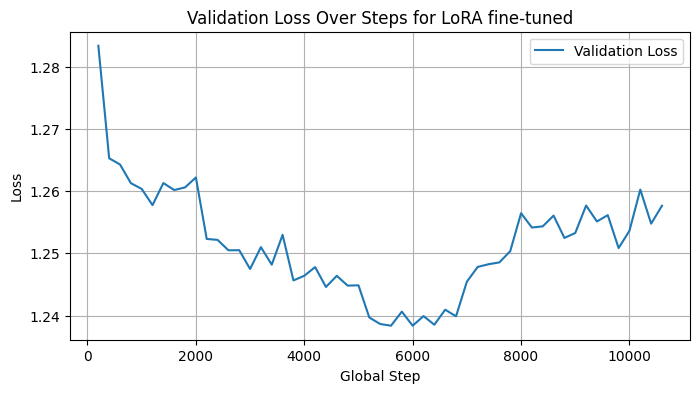

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(steps, val_losses, label='Validation Loss')
plt.xlabel('Global Step')
plt.ylabel('Loss')
plt.title('Validation Loss Over Steps for LoRA fine-tuned')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print(train_losses, val_losses)

[1.1540931463241577, 2.8716182708740234, 1.2854899168014526, 1.6168094873428345, 0.4839451313018799, 1.5083140134811401, 1.5777522325515747, 1.1588248014450073, 0.88433438539505, 0.9806851744651794, 1.9369001388549805, 1.9399869441986084, 1.412766456604004, 1.3740134239196777, 1.36656653881073, 0.9704115390777588, 0.7248150110244751, 0.8178530335426331, 1.7855170965194702, 1.3362616300582886, 0.3942095935344696, 1.408838152885437, 0.4954613745212555, 1.4804604053497314, 1.807072639465332, 0.46729761362075806, 1.0324983596801758, 1.23041570186615, 2.023528814315796, 1.973918080329895, 0.10342144221067429, 0.24185898900032043, 0.06981633603572845, 1.9121299982070923, 1.8188648223876953, 1.8539854288101196, 1.743744134902954, 1.2085468769073486, 1.3895232677459717, 0.5844010710716248, 0.462773859500885, 2.0894622802734375, 1.086700677871704, 0.18453332781791687, 0.38892388343811035, 0.003940023947507143, 0.14658714830875397, 1.5253008604049683, 0.7594854831695557, 2.427060842514038, 1.384

#**Set up for QLora**

In [ ]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

In [ ]:
# model download
model_id = "meta-llama/Llama-2-7b-hf"
base_model_qlora = LlamaForCausalLM.from_pretrained(model_id, quantization_config=bnb_config)
base_model_qlora.model_name = model_id
base_tokenizer_qlora = AutoTokenizer.from_pretrained(model_id)
base_tokenizer_qlora.pad_token = base_tokenizer_qlora.eos_token
base_model_qlora.config.pad_token_id = base_tokenizer_qlora.pad_token_id

config.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/188 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/776 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

In [ ]:
#Set all weights freeze
for param in base_model_qlora.parameters():
    param.requires_grad = False

In [ ]:
# ratio of trainable / total
total_trainable_params = sum(p.numel() for p in base_model_qlora.parameters() if p.requires_grad)
total_prams= sum(p.numel() for p in base_model_qlora.parameters())
print(total_trainable_params/total_prams)

0.0


In [ ]:
#preprocess the quantized model for training. now quantized model is ready
base_model_qlora = prepare_model_for_kbit_training(base_model_qlora)

In [ ]:
print(base_model_qlora)

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 4096)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (v_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (o_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear4bit(in_features=4096, out_features=11008, bias=False)
          (up_proj): Linear4bit(in_features=4096, out_features=11008, bias=False)
          (down_proj): Linear4bit(in_features=11008, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
      )
    )
    (norm): LlamaRMS

In [ ]:
rank = 1
alpha = 2

In [ ]:
attach_Lora_to_Linear(base_model_qlora, rank, alpha)
base_model_qlora.to(device)

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 4096)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): LayerWithLoRA(
            (base): Linear4bit(in_features=4096, out_features=4096, bias=False)
          )
          (k_proj): LayerWithLoRA(
            (base): Linear4bit(in_features=4096, out_features=4096, bias=False)
          )
          (v_proj): LayerWithLoRA(
            (base): Linear4bit(in_features=4096, out_features=4096, bias=False)
          )
          (o_proj): LayerWithLoRA(
            (base): Linear4bit(in_features=4096, out_features=4096, bias=False)
          )
        )
        (mlp): LlamaMLP(
          (gate_proj): LayerWithLoRA(
            (base): Linear4bit(in_features=4096, out_features=11008, bias=False)
          )
          (up_proj): LayerWithLoRA(
            (base): Linear4bit(in_features=4096, out_features=11008, bias=False)
          )
          (d

In [ ]:
# ratio of trainable / total
total_trainable_params = sum(p.numel() for p in base_model_qlora.parameters() if p.requires_grad)
total_prams= sum(p.numel() for p in base_model_qlora.parameters())
print(total_trainable_params/total_prams)

0.0007132809403147557


In [ ]:
max_length = 512
batch_size=2


In [ ]:
dataset = DollyDataset(ds['train'], base_tokenizer_qlora, max_length)

In [ ]:
size = len(dataset)
train_size = int(0.8* size)
val_size = int(0.1 * size)
test_size = size - train_size - val_size
train_ds, val_ds, test_ds = torch.utils.data.random_split(dataset, [train_size, val_size, test_size], generator=torch.Generator().manual_seed(42))

In [ ]:
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

# **Fine-tuning with QLoRA**

In [ ]:
lr = 5e-5
epochs = 2
optimizer = torch.optim.AdamW(base_model_qlora.parameters(), lr=lr)

In [ ]:
train_losses, val_losses, steps = train_lora(base_model_qlora, optimizer, train_loader, val_loader, epochs, device, 'nf4')

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


epoch 1 | step 200 | train_loss 0.7012 | val_loss 1.3145
epoch 1 | step 400 | train_loss 1.8515 | val_loss 1.3017
epoch 1 | step 600 | train_loss 0.8062 | val_loss 1.2957
epoch 1 | step 800 | train_loss 0.6244 | val_loss 1.2985
epoch 1 | step 1000 | train_loss 0.3589 | val_loss 1.2925
epoch 1 | step 1200 | train_loss 1.7973 | val_loss 1.2900
epoch 1 | step 1400 | train_loss 1.6975 | val_loss 1.2854
epoch 1 | step 1600 | train_loss 1.7599 | val_loss 1.2978
epoch 1 | step 1800 | train_loss 1.9449 | val_loss 1.2847
epoch 1 | step 2000 | train_loss 1.2127 | val_loss 1.2827
epoch 1 | step 2200 | train_loss 1.4516 | val_loss 1.2814
epoch 1 | step 2400 | train_loss 0.3391 | val_loss 1.2800
epoch 1 | step 2600 | train_loss 1.1925 | val_loss 1.2806
epoch 1 | step 2800 | train_loss 1.5014 | val_loss 1.2789
epoch 1 | step 3000 | train_loss 0.6992 | val_loss 1.2777
epoch 1 | step 3200 | train_loss 1.4095 | val_loss 1.2776
epoch 1 | step 3400 | train_loss 0.7679 | val_loss 1.2760
epoch 1 | step 360

# Train and validation loss curve

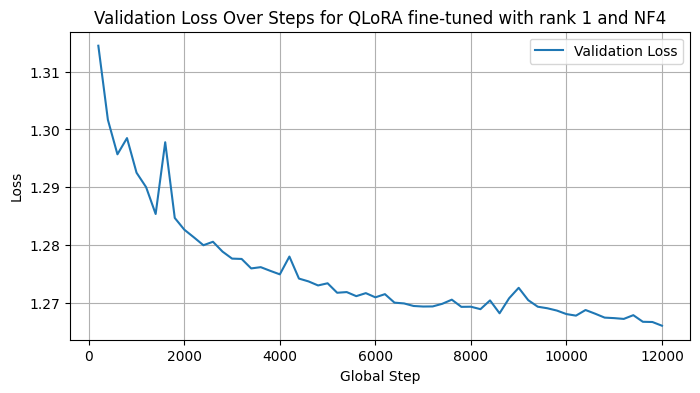

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(steps, val_losses, label='Validation Loss')
plt.xlabel('Global Step')
plt.ylabel('Loss')
plt.title('Validation Loss Over Steps for QLoRA fine-tuned with rank 1 and NF4')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print(val_losses)

[1.2988800523877144, 1.2920311386684578, 1.2774909612188736, 1.2722325335641702, 1.2702473098846774, 1.2723718812068303, 1.2677935703918337, 1.265078574764232, 1.2636524955704809, 1.2627799886415403, 1.2617412390907605, 1.260382578159372, 1.2584164963712294, 1.2572935735397042, 1.2574411602318287, 1.2576684255152941, 1.2557881940727433, 1.2546275594234466, 1.2546168064922094, 1.254413307244579, 1.2533471905589104, 1.2515049930860598, 1.2509351165207723, 1.2514668413226804, 1.249633677771936, 1.251560712809364, 1.2493637382841358, 1.2500382598067323, 1.250860342079463, 1.2494713828054567, 1.2484340366292745, 1.2486445428337902, 1.2479489405130346, 1.2473334943130612, 1.2482484630992015, 1.2479326543873177, 1.2482529519399008, 1.2484804230226825, 1.2480465222448112, 1.2595390260803203, 1.2510325992392997, 1.250392846170813, 1.2519918782822788, 1.2499019303849588, 1.2506512599966177, 1.249341816391175, 1.2497194367361566, 1.248451224076251, 1.248829982156555, 1.249252829398339, 1.24946259

**Pre fine-tuned and base models**

In [ ]:
finetuned_model = LlamaForCausalLM.from_pretrained("meta-llama/Llama-2-7b-chat-hf")
finetuned_tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-2-7b-chat-hf")
base_model_lora = LlamaForCausalLM.from_pretrained("meta-llama/Llama-2-7b-hf")
base_tokenizer_lora = AutoTokenizer.from_pretrained("meta-llama/Llama-2-7b-hf")

config.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/188 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

# Part 4: Run Hyperparameter Experiments

The base model itself is pretty strong, so change in learning hyper parameter, such as epochs, batch, or learning rate will not have a significant effect on the accuracy. Also, the model I chose is too large to run again and again in short time. It actually takes 3 hours for 2 epochs with even efficient fine-tuning. I decided to pick two architecture hyper parameter, rank size, and bits type they store for QLoRA as hyperparameter I will look into. This is because rank of LoRA and nf4 bits are big points of this technique and I can show how those parameter have effect on the model performance. However, as I said base model has strong power, so it might not have huge difference by change of rank.

Actually, I can't run real hyperparameter grid searches loop because I am using colab, and it will be terminated at some point. Therefore, I will run 4 configurations (float4bits, NF4bits) × (rank 1, rank 16) above one by one, and store the best performance models, and check their accuracy on test dataset by loading model here, and show the grid heatmap.

I know my grid searches over hyper parameters are not adequate, and I already talked with professor about this problem. He suggested me to conduct at least small grid search. I also have implemented performance comparison with models I trained, base models, and models fine-tuned by meta on test dataset, and done analysis on accuracy as gap-fill. sorry about that.





*   I actually wanted to try rank 4 as well for the parameter grid search, but when I have done 4 combinations, my compute units I had on colab was 1,76, so I could not have run them.
*   I run all 4 configurations and saved checkpoints of 2-3 best models for each. However, as I mentioned I consumed all my compute units, and I actually used my friends compute units too to train models. My friend's account had more compute units, so I could have run more, but to run testing, I need to have my saved checkpoints files in his google drive or temperary folder on colab. His drive had only 15 GB, so I could not have them moved there, and temperary folder could not save my pt files because they were too huge. I have been trying to get access to GPU. First, I tried other google account for student offer, but they did not have free offer for colab pro. I also tried using chpc, and I have done all setup on it, but Once I tried to load my models, my kernel repeatedly got disconected. I assumed this is because GPU they had and I had access to was a little old. I have tried 2080ti and 1080ti, but both did not work. Chpc has A100 or H100, but I do not have access to it. I spent entire 1.5 days for getting access to GPU, and could not have made it.
* what I was planning to do was first comparing those 4 configuration models by their loss on test dataset, and get the best parameter. I have saved pictures of all validation losses results, and as I expected, rank 16 NF4 bits model did best performance though loss difference between configurations is quite small. After that, I wanted to compare the performance of base model, full fine-tuned model, LoRA fine-tuned, and QLoRA fine-tuned models by comparing texts they generate against test dataset instruction and contexts, and check which one is correct or not by human. For this part if you have any better idea. Please let me know. I could not find best way.




In [ ]:
check_pt_dir = "Check_pt/llama_2_7B_Manually_16_nf4_checkpoint_step_12000.pt"
#llama_2_7B_Manually_1_nf4_checkpoint_step_12000.pt
#llama_2_7B_Manually_1_fp4_checkpoint_step_11200.pt
#llama_2_7B_Manually_16_fp4_checkpoint_step_6200.pt
#llama_2_7B_Manually_16_fp4_checkpoint_step_6200.pt
#llama_2_7B_Manually__checkpoint_step_6400.pt
# check points for best models for each configurations

In [ ]:
test_model, optimizer, epoch, global_step, train_loss, val_loss = load_model(check_pt_dir)


In [ ]:
model_id = "meta-llama/Llama-2-7b-hf"
test_tokenizer= AutoTokenizer.from_pretrained("meta-llama/Llama-2-7b-hf")
test_tokenizer_lora.pad_token = test_tokenizer.eos_token
test_model.config.pad_token_id = test_tokenizer_lora.pad_token_id

In [ ]:
max_length = 512
batch_size=2

In [ ]:
dataset = DollyDataset(ds['train'], test_tokenizer, max_length)

In [ ]:
size = len(dataset)
train_size = int(0.8* size)
val_size = int(0.1 * size)
test_size = size - train_size - val_size
train_ds, val_ds, test_ds = torch.utils.data.random_split(dataset, [train_size, val_size, test_size], generator=torch.Generator().manual_seed(42))

In [ ]:
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=True)

In [ ]:
test_loss = evaluate(test_model, device, test_loader)

In [ ]:
# TODO - perform hyperparameter grid searches and plot accuracies
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
results = [{"rank":1, "quant_bits": 'fp4', "loss": ...}] # This is the results I was supposed to get
# 1. Convert your list to a pandas DataFrame
df = pd.DataFrame(results)

# 2. Reshape into a 2D matrix
# Y-axis (index) = quant bits, X-axis (columns) = rank, Cells = loss
heatmap_data = df.pivot(index='quant_bits', columns='rank', values='loss')

# 3. Plot the heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(heatmap_data, annot=True, cmap='viridis', fmt='.3f', cbar_kws={'label': 'test loss'})

plt.title('Hyperparameter Grid Search\n LoRA rank vs. quantized bits')
plt.xlabel('rank')
plt.ylabel('quantized bits')

plt.show()

In [ ]:
# TODO - other experiments
# I was planning to compare accuracy on base model, full fine-tuned model by meta, my LoRA model, and my QLoRA model.
# I was trying to figure out how I can implement comparison in accuracy, but I could not get the best way of doing it.
# LLM does not gives us 1 to 1 answers. It will give me answer texts, which is not always same.
# Therefore, I tried to do evaluation by letting them generate texts, and make sure it is correct answer against given prompt by human or judge by LLM
# judge by LLM might not be realistic idea because I might need to pay for the api as far as I know.

In [ ]:
# TODO - calculate the final test accuracy

TODO - Explain your experiments above. See assignment doc for more details.